In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")


  


In [2]:
df = pd.read_csv("../data/zomato_feature_engineered.csv")
 
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
 
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset Shape: (3448, 25)
Columns: ['name', 'cuisines', 'area', 'timing', 'full_address', 'ishomedelivery', 'istakeaway', 'isindoorseating', 'isvegonly', 'dinner_ratings', 'dinner_reviews', 'delivery_ratings', 'delivery_reviews', 'knownfor', 'populardishes', 'peopleknownfor', 'averagecost', 'total_reviews', 'demand_score', 'cost_index', 'cuisine_count', 'area_demand_score', 'restaurant_density', 'opportunity_score', 'area_avg_rating']


In [3]:
df["delivery_ratings"] = pd.to_numeric(df["delivery_ratings"], errors="coerce")
df["dinner_ratings"]   = pd.to_numeric(df["dinner_ratings"],   errors="coerce")
 
df["high_rated"] = (df["dinner_ratings"] >= 4.0).astype(int)
print("\nTarget Distribution:")
print(df["high_rated"].value_counts())
print(f"High rated restaurants: {df['high_rated'].mean()*100:.1f}%")
 


Target Distribution:
high_rated
0    2538
1     910
Name: count, dtype: int64
High rated restaurants: 26.4%


In [4]:
features = [
    # "dinner_ratings",
    # "dinner_reviews",
    "delivery_reviews",
    "averagecost",
    "ishomedelivery",
    "istakeaway",
    "isindoorseating",
    "isvegonly",
    "cuisine_count",
    "restaurant_density",
    # "cost_index",
    "demand_score",
    "opportunity_score",
    "area_avg_rating"
]
features = [f for f in features if f in df.columns]
print(f"\nUsing {len(features)} features: {features}")
 
ml_df = df[features + ["high_rated"]].dropna()
print(f"ML-ready rows: {len(ml_df)}")
 
X = ml_df[features]
y = ml_df["high_rated"]


Using 11 features: ['delivery_reviews', 'averagecost', 'ishomedelivery', 'istakeaway', 'isindoorseating', 'isvegonly', 'cuisine_count', 'restaurant_density', 'demand_score', 'opportunity_score', 'area_avg_rating']
ML-ready rows: 3448


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
 
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 2758 | Test size: 690


In [6]:
lr = LogisticRegression(max_iter=1000, random_state=42,class_weight="balanced")
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
lr_acc = accuracy_score(y_test, lr_preds)
 
print("\n" + "="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(f"Accuracy: {lr_acc*100:.2f}%")
print(classification_report(y_test, lr_preds, target_names=["Low Rated", "High Rated"]))


LOGISTIC REGRESSION RESULTS
Accuracy: 79.28%
              precision    recall  f1-score   support

   Low Rated       0.89      0.82      0.85       508
  High Rated       0.59      0.73      0.65       182

    accuracy                           0.79       690
   macro avg       0.74      0.77      0.75       690
weighted avg       0.81      0.79      0.80       690



In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
 
print("\n" + "="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(f"Accuracy: {rf_acc*100:.2f}%")
print(classification_report(y_test, rf_preds, target_names=["Low Rated", "High Rated"]))


RANDOM FOREST RESULTS
Accuracy: 80.72%
              precision    recall  f1-score   support

   Low Rated       0.84      0.92      0.88       508
  High Rated       0.68      0.50      0.58       182

    accuracy                           0.81       690
   macro avg       0.76      0.71      0.73       690
weighted avg       0.80      0.81      0.80       690



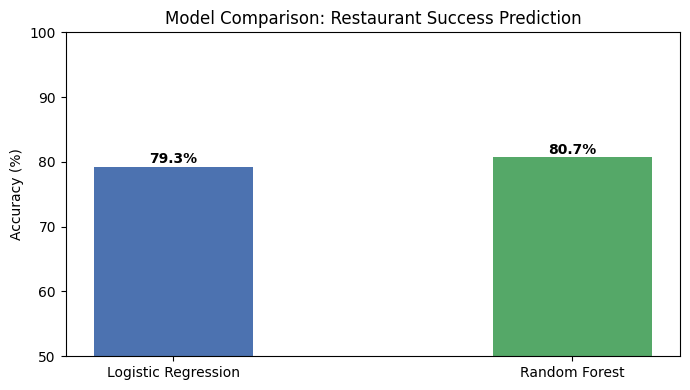

Saved: model_comparison.png


In [8]:
plt.figure(figsize=(7, 4))
model_names = ["Logistic Regression", "Random Forest"]
accuracies = [lr_acc * 100, rf_acc * 100]
colors = ["#4C72B0", "#55A868"]
bars = plt.bar(model_names, accuracies, color=colors, width=0.4)
plt.ylim(50, 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison: Restaurant Success Prediction")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{acc:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/model_comparison.png", dpi=150)
plt.show()
print("Saved: model_comparison.png")

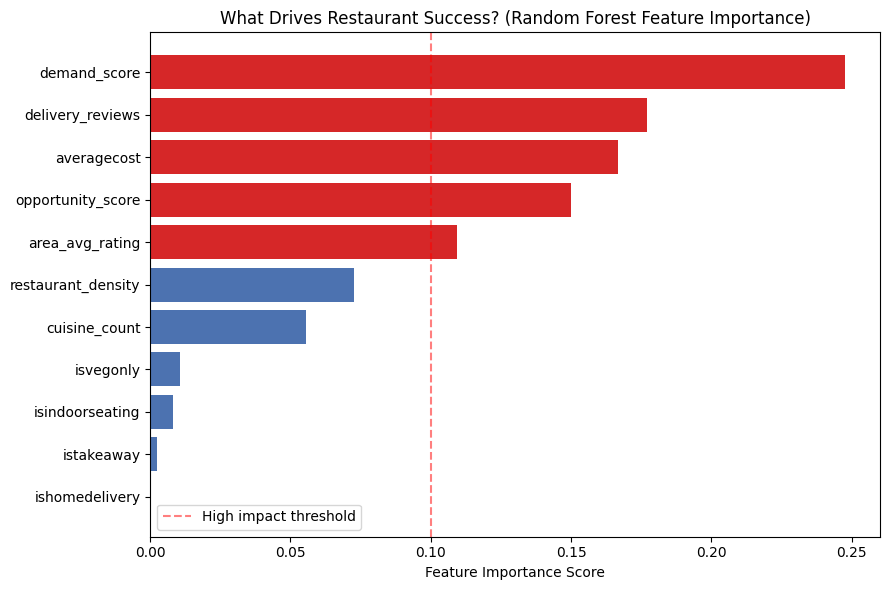

Saved: feature_importance.png

Top 5 Most Important Features:
          Feature  Importance
     demand_score    0.247736
 delivery_reviews    0.177093
      averagecost    0.166588
opportunity_score    0.149860
  area_avg_rating    0.109478


In [9]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)
 
plt.figure(figsize=(9, 6))
colors_imp = ["#d62728" if imp > 0.1 else "#4C72B0" for imp in importance_df["Importance"]]
plt.barh(importance_df["Feature"], importance_df["Importance"], color=colors_imp)
plt.xlabel("Feature Importance Score")
plt.title("What Drives Restaurant Success? (Random Forest Feature Importance)")
plt.axvline(0.1, color="red", linestyle="--", alpha=0.5, label="High impact threshold")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150)
plt.show()
print("Saved: feature_importance.png")
 
print("\nTop 5 Most Important Features:")
print(importance_df.sort_values("Importance", ascending=False).head(5).to_string(index=False))

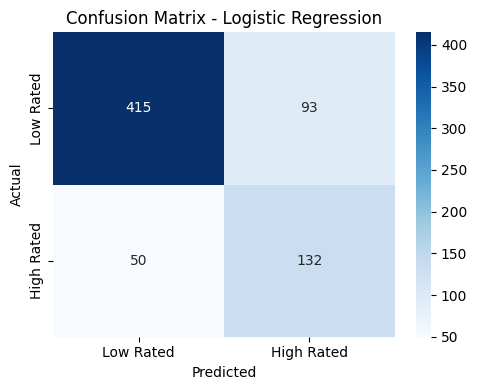

Saved: confusion_matrix.png


In [10]:
from sklearn.metrics import f1_score

lr_f1 = f1_score(y_test, lr_preds, pos_label=1)
rf_f1 = f1_score(y_test, rf_preds, pos_label=1)

best_preds = lr_preds if lr_f1 >= rf_f1 else rf_preds
best_name = "Logistic Regression" if lr_f1 >= rf_f1 else "Random Forest"
# best_preds = rf_preds if rf_acc >= lr_acc else lr_preds
# best_name  = "Random Forest" if rf_acc >= lr_acc else "Logistic Regression"
 
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Rated", "High Rated"],
            yticklabels=["Low Rated", "High Rated"])
plt.title(f"Confusion Matrix - {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

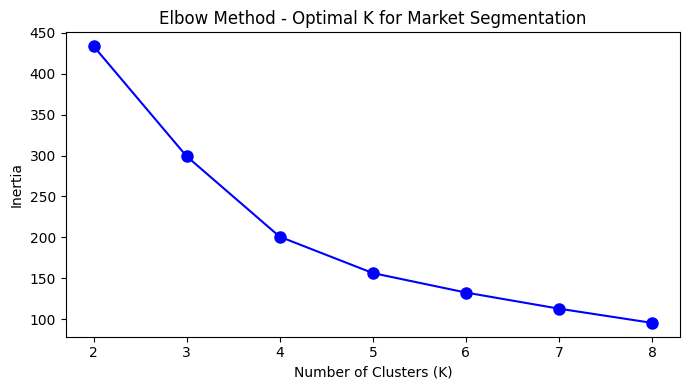

Saved: elbow_method.png

Cluster Profiles:
         restaurant_count  avg_delivery_rating  avg_demand_score  \
cluster                                                            
0                   11.92                 3.98           1704.27   
1                   97.68                 3.94           3419.88   
2                    1.30                 3.98           5074.76   
3                    1.38                 3.12            385.02   

         avg_opportunity  
cluster                   
0                 362.03  
1                  43.09  
2                4295.62  
3                 271.67  


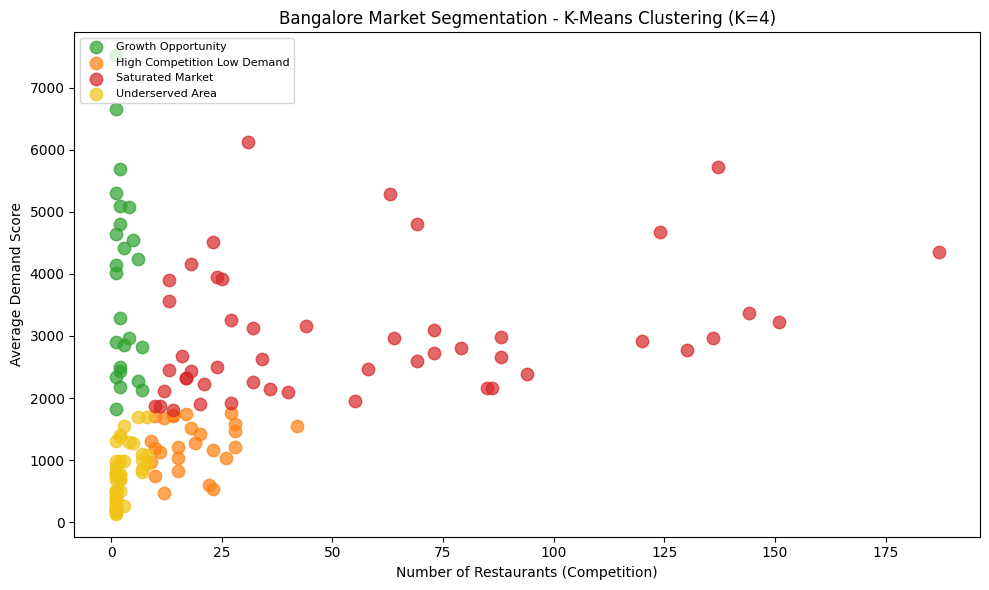

Saved: market_clustering.png

TOP GROWTH OPPORTUNITY AREAS (Best for Expansion):
                                                             area  restaurant_count  avg_delivery_rating  avg_demand_score
                                      153 Biere Street, Bangalore                 1             4.200000       7523.600000
                             Total Mall, Sarjapur Road, Bangalore                 1             4.000000       6656.600000
                          Bangalore Central, Bellandur, Bangalore                 2             3.800000       5687.750000
Aloft Bengaluru Cessna Business Park, Kadubeesanahalli, Bangalore                 1             4.100000       5305.800000
                 Gopalan Innovation Mall, Bannerghatta, Bangalore                 2             3.800000       5096.250000
                        Brookefields Mall, Brookefield, Bangalore                 4             3.975000       5076.825000
                                KBR Mall, Marathahalli, Ba

In [11]:
area_df = df.groupby("area").agg(
    restaurant_count    = ("name", "count"),
    avg_delivery_rating = ("delivery_ratings", "mean"),
    avg_demand_score    = ("demand_score", "mean"),
    avg_opportunity     = ("opportunity_score", "mean"),
    avg_cost            = ("averagecost", "mean")
).reset_index().dropna()
 
cluster_features = [
    "restaurant_count",
    "avg_delivery_rating",
    "avg_demand_score",
    "avg_opportunity"
]
scaler2 = StandardScaler()
X_cluster = scaler2.fit_transform(area_df[cluster_features])
 
# Elbow method
inertia = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)
 
plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, "bo-", markersize=8)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Optimal K for Market Segmentation")
plt.tight_layout()
plt.savefig("../outputs/elbow_method.png", dpi=150)
plt.show()
print("Saved: elbow_method.png")
 
# Apply K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
area_df["cluster"] = kmeans.fit_predict(X_cluster)
 
cluster_summary = area_df.groupby("cluster")[cluster_features].mean()
print("\nCluster Profiles:")
print(cluster_summary.round(2))
 
# Business labels
def label_cluster(row):
    density = row["restaurant_count"]
    demand  = row["avg_demand_score"]
    d_med   = area_df["restaurant_count"].median()
    dem_med = area_df["avg_demand_score"].median()
    if density >= d_med and demand >= dem_med:
        return "Saturated Market"
    elif density < d_med and demand >= dem_med:
        return "Growth Opportunity"
    elif density < d_med and demand < dem_med:
        return "Underserved Area"
    else:
        return "High Competition Low Demand"
 
area_df["market_zone"] = area_df.apply(label_cluster, axis=1)
 
# Cluster scatter plot
plt.figure(figsize=(10, 6))
colors_map = {
    "Saturated Market":            "#d62728",
    "Growth Opportunity":          "#2ca02c",
    "Underserved Area":            "#f0c417",
    "High Competition Low Demand": "#ff7f0e"
}
for zone, grp in area_df.groupby("market_zone"):
    plt.scatter(grp["restaurant_count"], grp["avg_demand_score"],
                label=zone, color=colors_map[zone], alpha=0.7, s=80)
 
plt.xlabel("Number of Restaurants (Competition)")
plt.ylabel("Average Demand Score")
plt.title("Bangalore Market Segmentation - K-Means Clustering (K=4)")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/market_clustering.png", dpi=150)
plt.show()
print("Saved: market_clustering.png")
 
print("\nTOP GROWTH OPPORTUNITY AREAS (Best for Expansion):")
growth = area_df[area_df["market_zone"] == "Growth Opportunity"]
print(growth[["area", "restaurant_count", "avg_delivery_rating",
              "avg_demand_score"]].sort_values(
              "avg_demand_score", ascending=False).to_string(index=False))
 

In [12]:
area_df.to_csv("../data/area_market_zones.csv", index=False)
print("area_df saved")

area_df saved


In [13]:
print("\n" + "="*60)
print("PROJECT ML SUMMARY")
print("="*60)
print(f"  Dataset            : 8,923 restaurants -> 3,448 after cleaning")
print(f"  ML Task            : Predict restaurant success (high/low rated)")
print(f"  Logistic Regression: {lr_acc*100:.1f}% accuracy")
print(f"  Random Forest      : {rf_acc*100:.1f}% accuracy")
print(f"  Clustering         : K-Means (K=4) -> 4 market zone types")
print(f"  Areas segmented    : {len(area_df)} unique areas in Bangalore")
print(f"  Growth zones found : {len(growth)} areas ideal for expansion")
print("="*60)
best_model_name = "Random Forest" if rf_f1 >= lr_f1 else "Logistic Regression"
best_acc = max(rf_acc, lr_acc) * 100
print(f"  Best Model         : {best_model_name} ({best_acc:.1f}%)")


PROJECT ML SUMMARY
  Dataset            : 8,923 restaurants -> 3,448 after cleaning
  ML Task            : Predict restaurant success (high/low rated)
  Logistic Regression: 79.3% accuracy
  Random Forest      : 80.7% accuracy
  Clustering         : K-Means (K=4) -> 4 market zone types
  Areas segmented    : 147 unique areas in Bangalore
  Growth zones found : 25 areas ideal for expansion
  Best Model         : Logistic Regression (80.7%)


In [14]:
import joblib
import os

os.makedirs("../app/models", exist_ok=True)

# Save Random Forest model
joblib.dump(rf, "../app/models/rf_model.pkl")

# Save KMeans model
joblib.dump(kmeans, "../app/models/kmeans_model.pkl")

# Save scaler (for clustering)
joblib.dump(scaler2, "../app/models/scaler.pkl")

# Save area dataframe with cluster labels
joblib.dump(area_df, "../app/models/area_df.pkl")

print("All models saved successfully!")

All models saved successfully!
